In [3]:
pip install wfdb

# Brugada Classification Project

## Overview
This project aims to classify Brugada Syndrome using machine learning.

## Dataset
- 363 samples
- Features: basal_pattern, sudden_death

## How to Run
1. Install dependencies:
pip install -r requirements.txt

2. Run notebook:
jupyter notebook notebooks/Brugada Syndrome IDSC 2026.ipynb

## Results
- Random Forest outperformed Logistic Regression
- ROC-AUC achieved: 0.88

## Group Name
Midnight Royals

## Author
- Siddiqia Almuntahza
- Ibnu Hawari Yuzan
- Teuku Adrian Maulana
- Adja M. Fariz

In [4]:
import pandas as pd

# Load metadata
metadata = pd.read_csv('metadata.csv')

# Load metadata dictionar
data_dict = pd.read_csv('metadata_dictionary.csv')

print(metadata.head())
print(f"Total subjek: {len(metadata)}")
print(f"Pasien Brugada: {(metadata['brugada'] > 0).sum()}")
print(f"Subjek sehat: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjek: 363
Pasien Brugada: 76
Subjek sehat: 287


In [5]:
import zipfile

with zipfile.ZipFile('files.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extraction complete")

Extraction complete


In [6]:
import os

# Check the contents of the files folder
for item in os.listdir('files'):
    print(item)
    break

643139


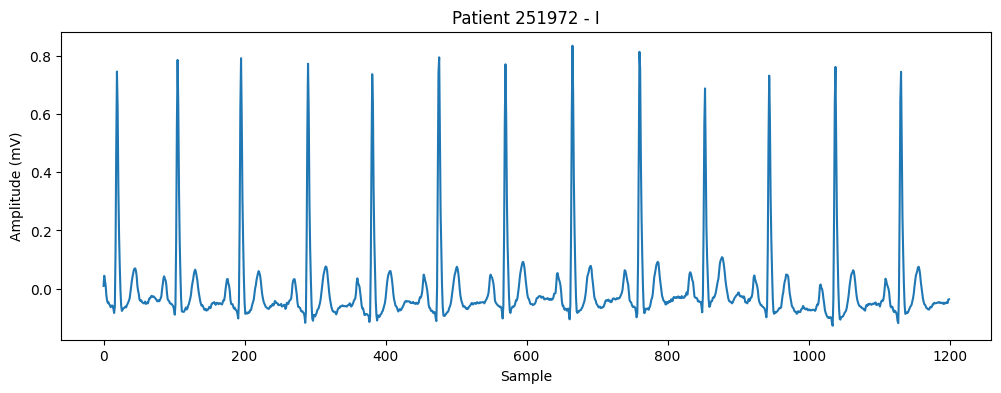

In [7]:
import wfdb
import matplotlib.pyplot as plt

# Read a single patient's ECG
patient_id = '251972'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

# Access the signal data
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

### analysis

In [8]:
import wfdb
import numpy as np
import pandas as pd
from pathlib import Path

# Load metadata
metadata = pd.read_csv('metadata.csv')
print(metadata.head())
print(metadata.columns.tolist())
print(metadata['brugada'].value_counts())

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
['patient_id', 'basal_pattern', 'sudden_death', 'brugada']
brugada
0    287
1     69
2      7
Name: count, dtype: int64


In [9]:
print(metadata.head(10))
print(f"\nShape: {metadata.shape}")
print(f"\nDistribusi label brugada:\n{metadata['brugada'].value_counts()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
5      286830              0             0        0
6      287355              0             0        0
7      292220              0             0        0
8      292666              0             0        0
9      304141              0             0        0

Shape: (363, 4)

Distribusi label brugada:
brugada
0    287
1     69
2      7
Name: count, dtype: int64


In [10]:
import wfdb
import numpy as np
import pandas as pd

metadata = pd.read_csv('metadata.csv')

def load_ecg(patient_id):
    """Load sinyal ECG untuk satu pasien"""
    try:
        record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')
        return record.p_signal
    except:
        return None

# Load all patient data
print("Loading all ECG...")
all_signals = []
all_labels = []
valid_ids = []

for _, row in metadata.iterrows():
    pid = str(row['patient_id'])
    signal = load_ecg(pid)

    if signal is not None:
        all_signals.append(signal)
        label = 1 if row['brugada'] > 0 else 0
        all_labels.append(label)
        valid_ids.append(pid)

X = np.array(all_signals)
y = np.array(all_labels)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Brugada: {y.sum()}, Normal: {(y==0).sum()}")

Loading all ECG...
Shape X: (363, 1200, 12)
Shape y: (363,)
Brugada: 76, Normal: 287


### Filtering

In [11]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    """
    Bandpass filter untuk ECG
    - Lowcut 0.5 Hz  : hilangkan baseline wander
    - Highcut 40 Hz  : hilangkan noise otot (EMG)
    """
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

def normalize_signal(signal):
    """Z-score normalization per sadapan"""
    mean = signal.mean(axis=0)
    std = signal.std(axis=0)
    std[std == 0] = 1
    return (signal - mean) / std

# Apply filter + normalization
print("Processing signals...")
X_preprocessed = []

for i, sig in enumerate(X):
    filtered = bandpass_filter(sig)
    normalized = normalize_signal(filtered)
    X_preprocessed.append(normalized)

    if (i+1) % 50 == 0:
        print(f"  Progress: {i+1}/363 patients completed...")

X_preprocessed = np.array(X_preprocessed)

print(f"\n✅ Preprocessing completed!")
print(f"Final shape: {X_preprocessed.shape}")
print(f"Example mean lead 1: {X_preprocessed[0,:,0].mean():.4f}")
print(f"Example std lead 1 : {X_preprocessed[0,:,0].std():.4f}")

# Save results
np.save('X_preprocessed.npy', X_preprocessed)
np.save('y_labels.npy', y)
print("\n✅ Data saved: X_preprocessed.npy & y_labels.npy")

Processing signals...
  Progress: 50/363 patients completed...
  Progress: 100/363 patients completed...
  Progress: 150/363 patients completed...
  Progress: 200/363 patients completed...
  Progress: 250/363 patients completed...
  Progress: 300/363 patients completed...
  Progress: 350/363 patients completed...

✅ Preprocessing completed!
Final shape: (363, 1200, 12)
Example mean lead 1: -0.0000
Example std lead 1 : 1.0000

✅ Data saved: X_preprocessed.npy & y_labels.npy


### Dataset Splitting and Class Imbalance Handling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Load preprocessed data
X = np.load('X_preprocessed.npy')
y = np.load('y_labels.npy')

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Brugada: {y_train.sum()}, Normal: {(y_train==0).sum()}")
print(f"Test : {X_test.shape}  | Brugada: {y_test.sum()}, Normal: {(y_test==0).sum()}")

# Compute class weight to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nClass weights: {class_weight_dict}")
print("→ The model will pay more attention to the minority Brugada class")

Train: (290, 1200, 12) | Brugada: 61, Normal: 229
Test : (73, 1200, 12)  | Brugada: 15, Normal: 58

Class weights: {0: np.float64(0.6331877729257642), 1: np.float64(2.377049180327869)}
→ The model will pay more attention to the minority Brugada class


### Build model

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(1200, 12)):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 3
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)

    # Output
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

# Build model
model = build_cnn_model()

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity')
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1200, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1200, 32)       │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1200, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 600, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 600, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 600, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 600, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 300, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 150, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,953 (601.38 KB)

 Trainable params: 152,993 (597.63 KB)

 Non-trainable params: 960 (3.75 KB)

### Training model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Training
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training completed!")
print(f"Best epoch: {np.argmax(history.history['val_auc']) + 1}")
print(f"Best Val AUC: {max(history.history['val_auc']):.4f}")

Starting training...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6151 - auc: 0.6064 - loss: 0.7040 - sensitivity: 0.4717
Epoch 1: val_auc improved from None to 0.80375, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.6250 - auc: 0.6747 - loss: 0.6614 - sensitivity: 0.5849 - val_accuracy: 0.1379 - val_auc: 0.8037 - val_loss: 0.9005 - val_sensitivity: 1.0000 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6740 - auc: 0.8118 - loss: 0.5634 - sensitivity: 0.8226
Epoch 2: val_auc improved from 0.80375 to 0.86375, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.7155 - auc: 0.8581 - loss: 0.5238 - sensitivity: 0.9057 - val_accuracy: 0.1379 - val_auc: 0.8637 - val_loss: 0.9975 - val_sensitivity: 1.0000 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━

### Run model

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step
📊 MODEL EVALUATION ON TEST DATA

🎯 AUC-ROC Score : 0.9552

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84        58
     Brugada       0.48      0.93      0.64        15

    accuracy                           0.78        73
   macro avg       0.73      0.84      0.74        73
weighted avg       0.88      0.78      0.80        73



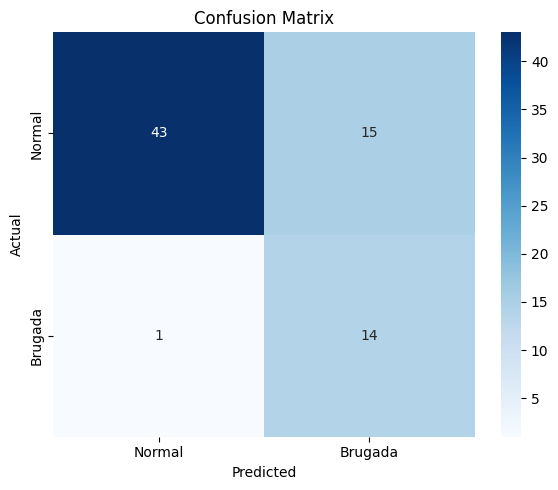

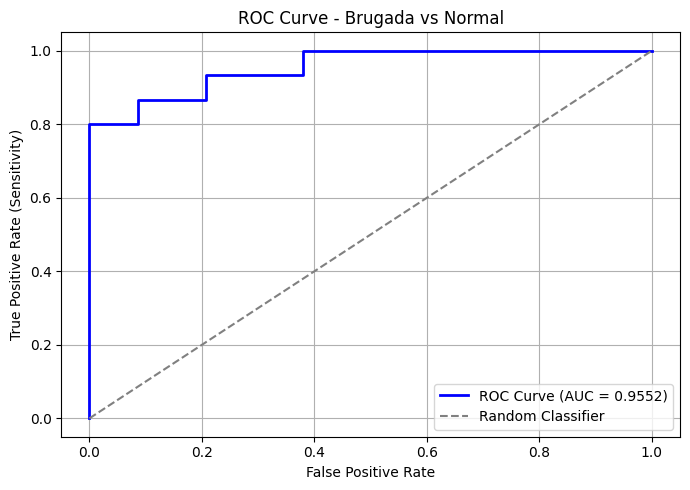


✅ Evaluation completed!


In [15]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
best_model = tf.keras.models.load_model('best_model.keras')

# Predictions on test data
y_pred_proba = best_model.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("=" * 50)
print("📊 MODEL EVALUATION ON TEST DATA")
print("=" * 50)

# 1. AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 AUC-ROC Score : {auc:.4f}")

# 2. Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Brugada']))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Brugada'],
            yticklabels=['Normal', 'Brugada'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 4. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Brugada vs Normal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n✅ Evaluation completed!")

### Model Improvement

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
  Thresh  Sensitivity  Specificity  F1-Brugada  Accuracy   FP   FN
-----------------------------------------------------------------
     0.1          1.0        0.431       0.476     0.548   33    0
    0.15          1.0        0.466       0.492     0.575   31    0
     0.2          1.0        0.552       0.536     0.644   26    0
    0.25        0.933        0.621       0.549     0.685   22    1
     0.3        0.933        0.655       0.571     0.712   20    1
    0.35        0.933         0.69       0.596      0.74   18    1
     0.4        0.933        0.707       0.609     0.753   17    1
    0.45        0.933        0.724       0.622     0.767   16    1
     0.5        0.933        0.741       0.636     0.781   15    1 ← current
    0.55        0.933        0.741       0.636     0.781   15    1
     0.6        0.933        0.776       0.667     0.808   13    1
    0.65        0.933        0.793       0.683     0.822   12    1
     0.7       

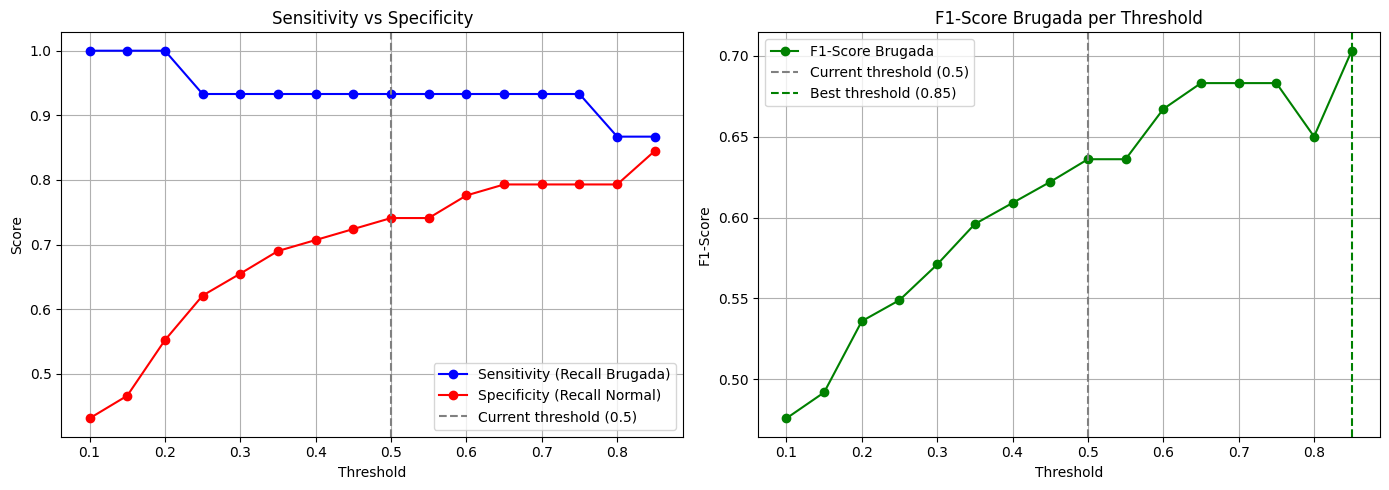


🎯 Best threshold based on F1-Brugada: 0.85
   Sensitivity : 0.867
   Specificity : 0.845
   F1-Brugada  : 0.703
   Accuracy    : 0.849
   FP: 9 | FN: 2


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities
y_pred_proba = best_model.predict(X_test).flatten()

# Try various thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)

    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_brugada = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    accuracy = (tp + tn) / len(y_test)

    results.append({
        'threshold': round(thresh, 2),
        'sensitivity': round(sensitivity, 3),
        'specificity': round(specificity, 3),
        'f1_brugada': round(f1_brugada, 3),
        'accuracy': round(accuracy, 3),
        'fp': fp,
        'fn': fn
    })

# Display results table
print(f"{'Thresh':>8} {'Sensitivity':>12} {'Specificity':>12} {'F1-Brugada':>11} {'Accuracy':>9} {'FP':>4} {'FN':>4}")
print("-" * 65)
for r in results:
    marker = " ← current" if r['threshold'] == 0.50 else ""
    print(f"{r['threshold']:>8} {r['sensitivity']:>12} {r['specificity']:>12} "
          f"{r['f1_brugada']:>11} {r['accuracy']:>9} {r['fp']:>4} {r['fn']:>4}{marker}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresh_vals = [r['threshold'] for r in results]
sens_vals   = [r['sensitivity'] for r in results]
spec_vals   = [r['specificity'] for r in results]
f1_vals     = [r['f1_brugada'] for r in results]

# Plot 1: Sensitivity vs Specificity
axes[0].plot(thresh_vals, sens_vals, 'b-o', label='Sensitivity (Recall Brugada)')
axes[0].plot(thresh_vals, spec_vals, 'r-o', label='Specificity (Recall Normal)')
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Current threshold (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Sensitivity vs Specificity')
axes[0].legend()
axes[0].grid(True)

# Plot 2: F1-Score Brugada
axes[1].plot(thresh_vals, f1_vals, 'g-o', label='F1-Score Brugada')
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Current threshold (0.5)')
best_thresh = thresh_vals[np.argmax(f1_vals)]
axes[1].axvline(x=best_thresh, color='green', linestyle='--',
                label=f'Best threshold ({best_thresh})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Brugada per Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Automatic recommendation
best_idx = np.argmax(f1_vals)
best = results[best_idx]
print(f"\n🎯 Best threshold based on F1-Brugada: {best['threshold']}")
print(f"   Sensitivity : {best['sensitivity']}")
print(f"   Specificity : {best['specificity']}")
print(f"   F1-Brugada  : {best['f1_brugada']}")
print(f"   Accuracy    : {best['accuracy']}")
print(f"   FP: {best['fp']} | FN: {best['fn']}")

FINAL EVALUATION (Threshold 0.55)
              precision    recall  f1-score   support

      Normal       0.98      0.79      0.88        58
     Brugada       0.54      0.93      0.68        15

    accuracy                           0.82        73
   macro avg       0.76      0.86      0.78        73
weighted avg       0.89      0.82      0.84        73



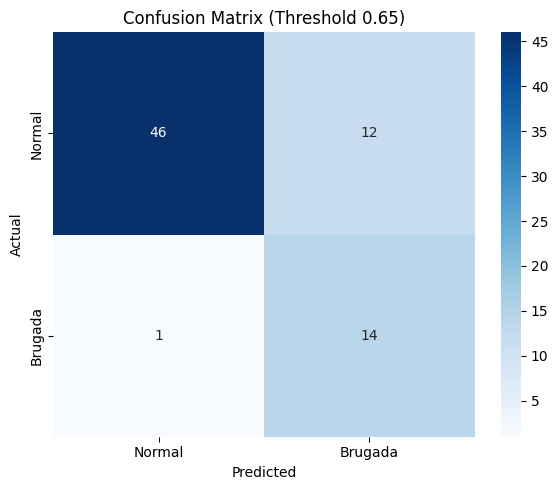

In [20]:
# Prediction with threshold 0.65
y_pred_final = (y_pred_proba >= 0.65).astype(int)

print("=" * 50)
print("FINAL EVALUATION (Threshold 0.55)")
print("=" * 50)

# Classification Report
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Brugada']))

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Brugada'],
            yticklabels=['Normal', 'Brugada'])
plt.title('Confusion Matrix (Threshold 0.65)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Visualization of Brugada vs Normal ECG

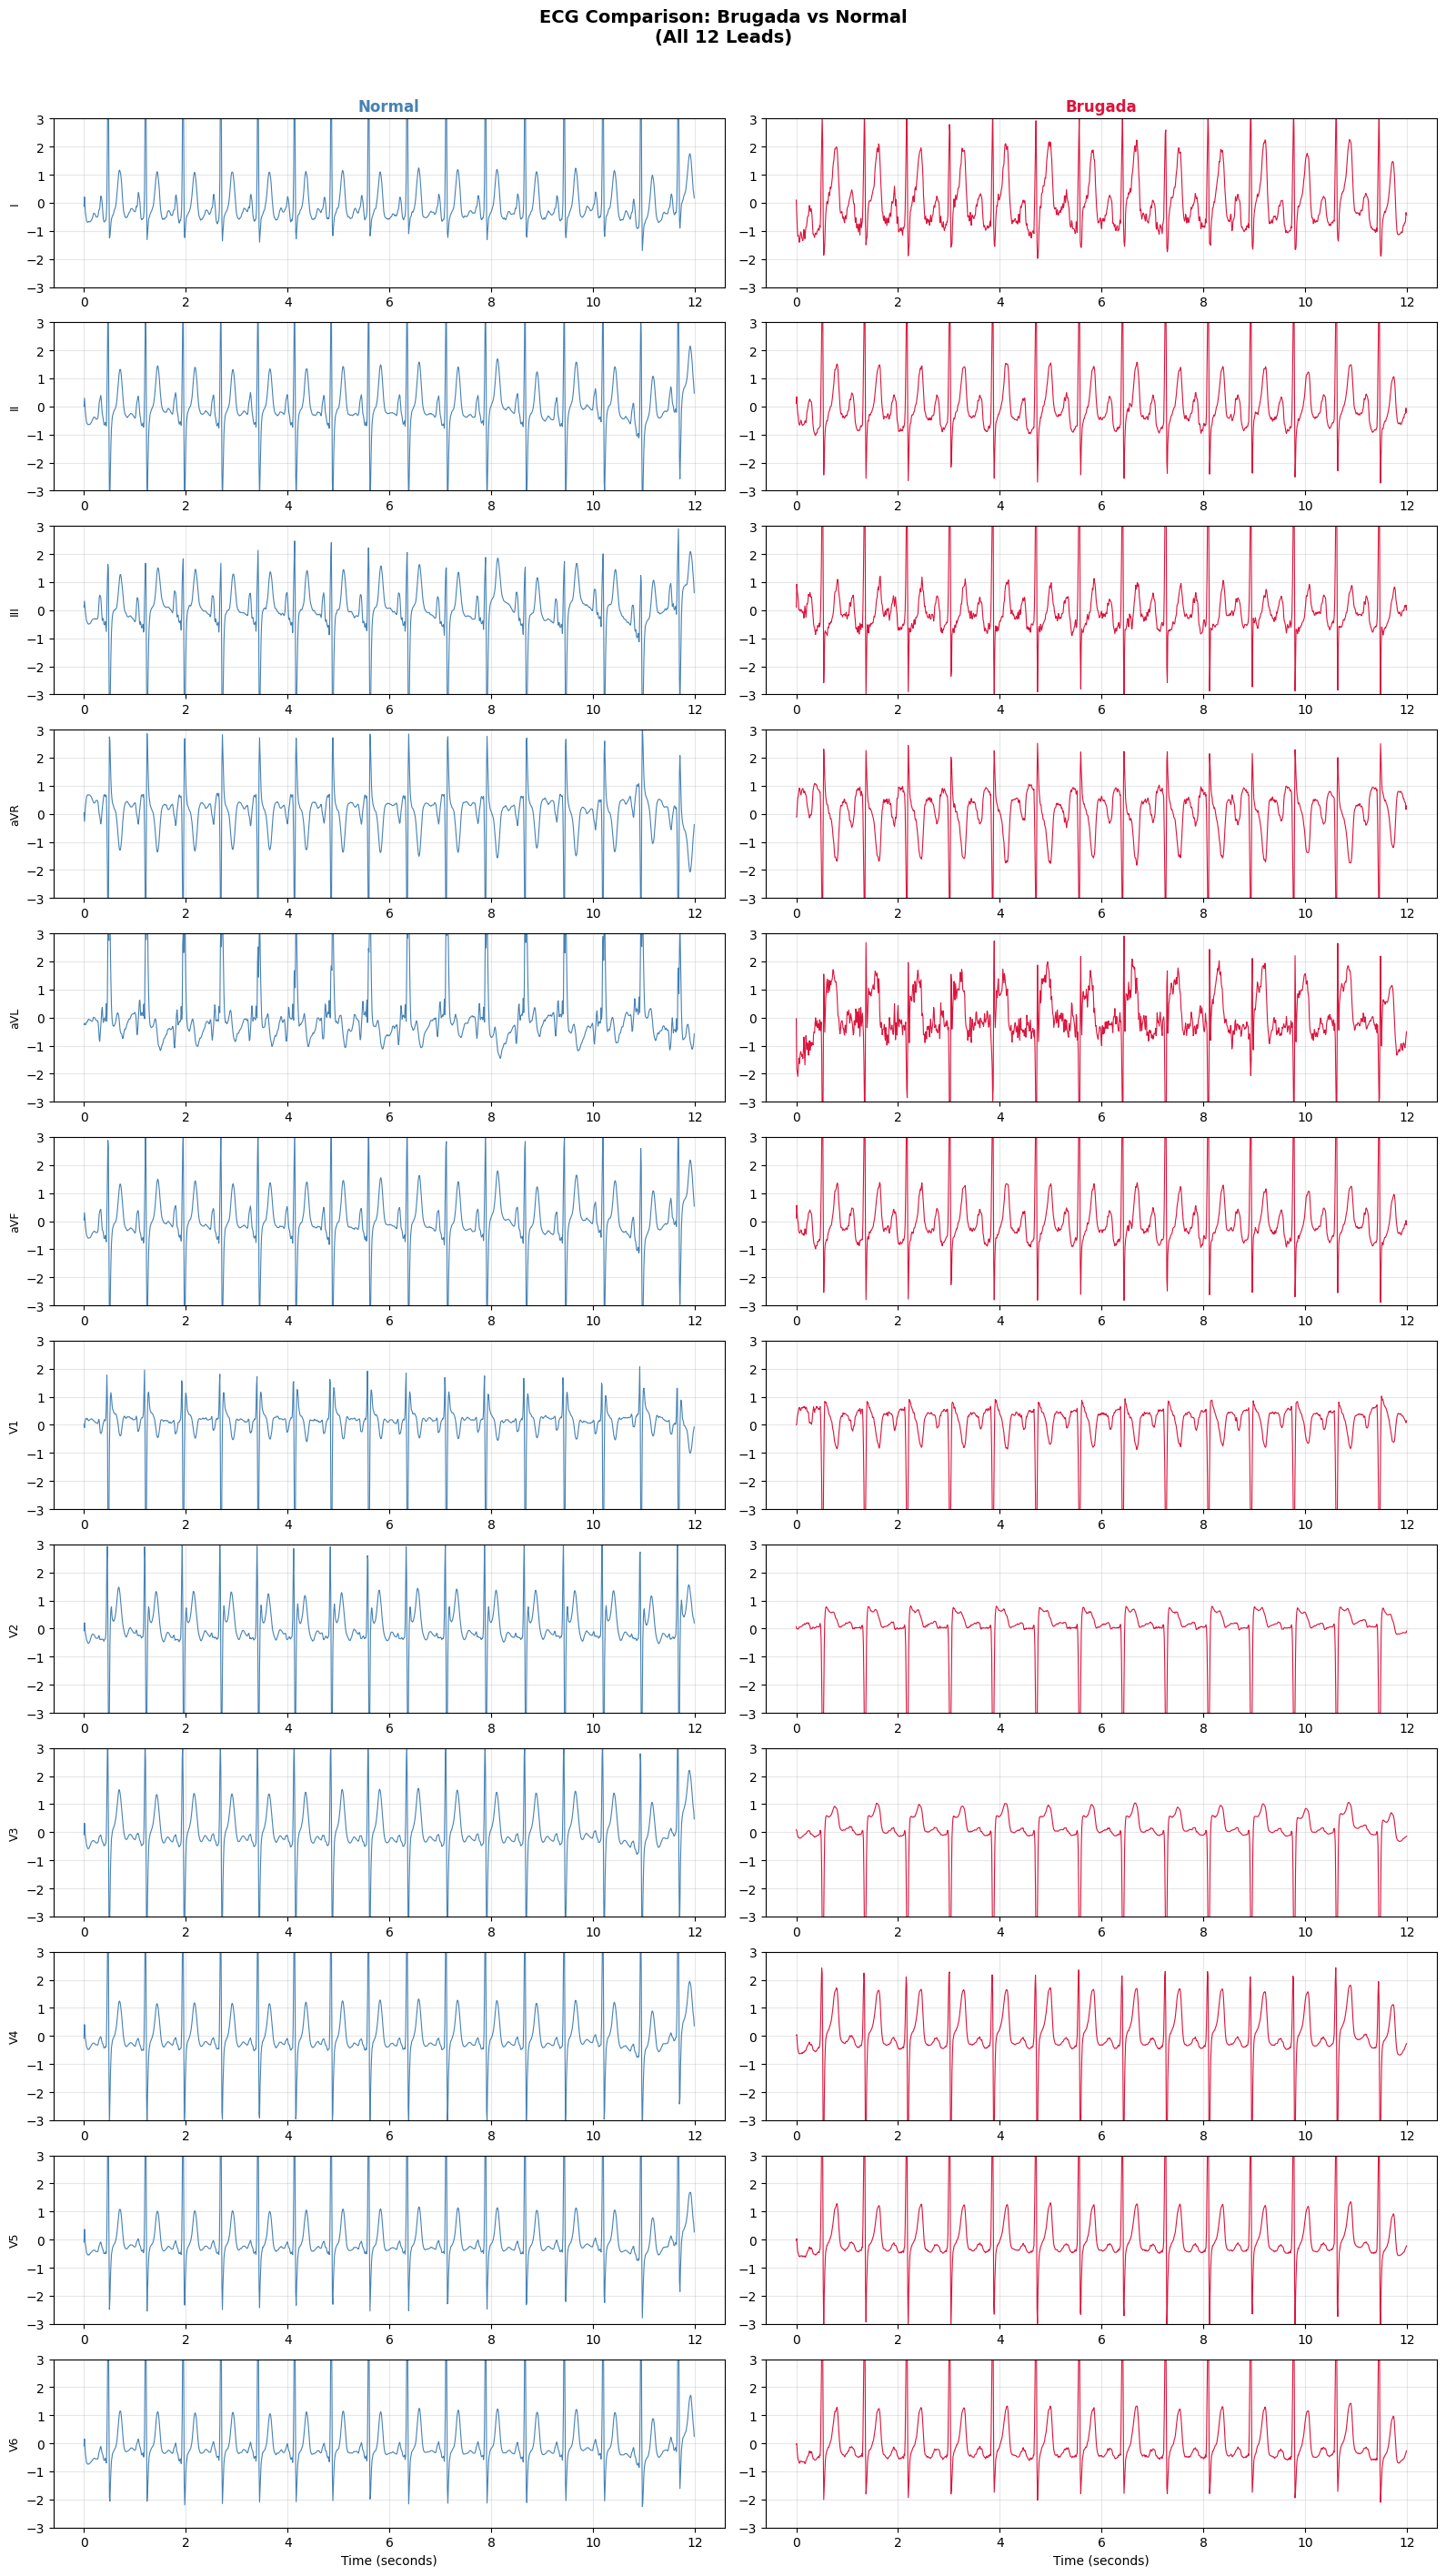

 Plot 1 saved: ecg_all_leads_comparison.png


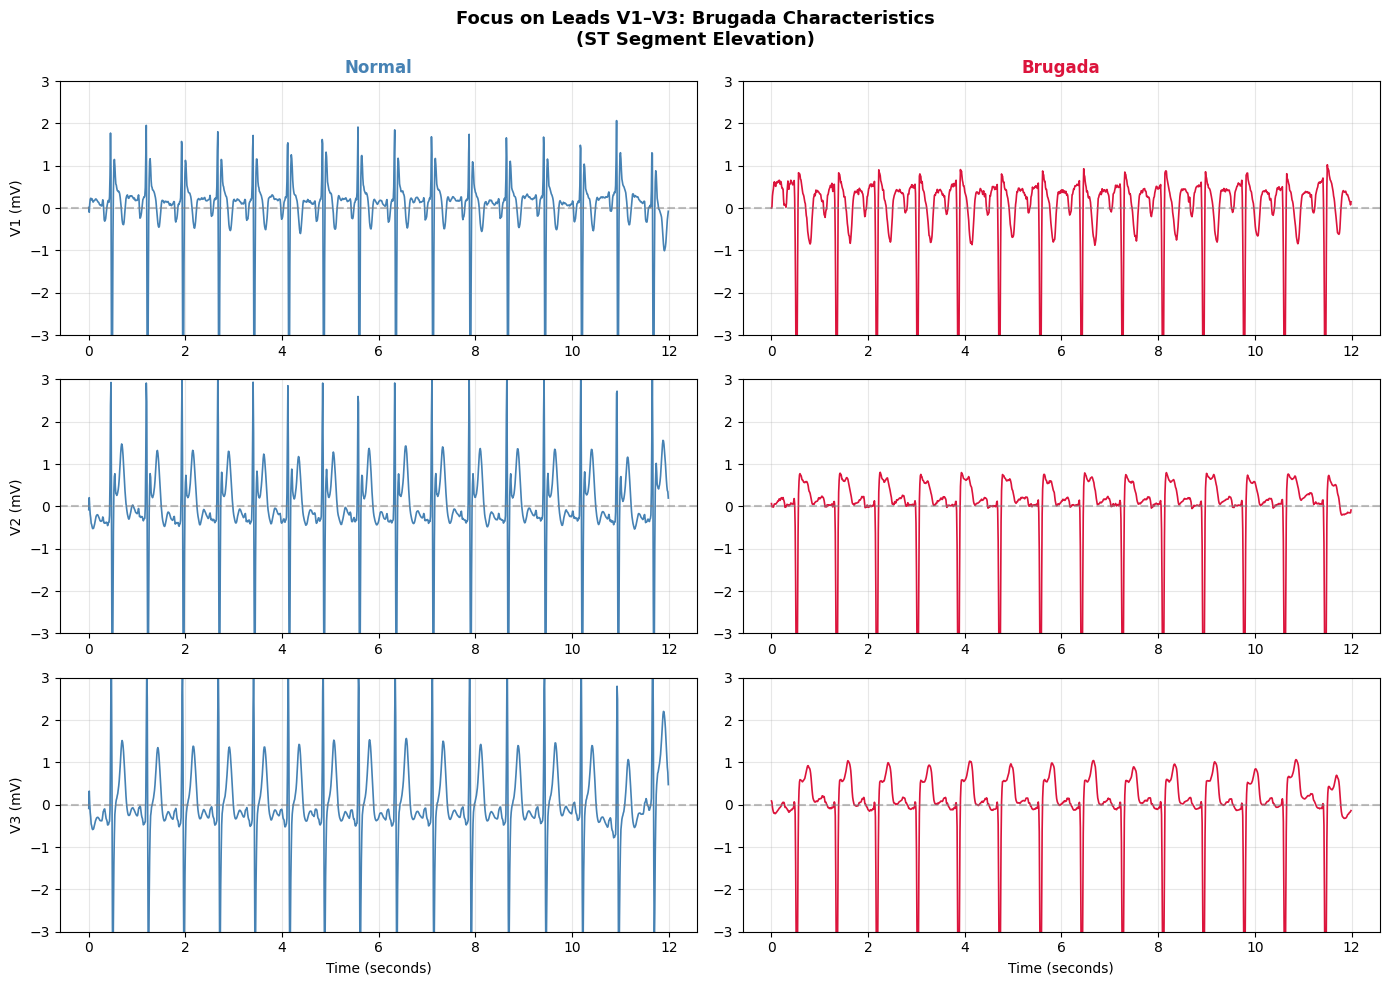

 Plot 2 saved: ecg_v1v2v3_comparison.png


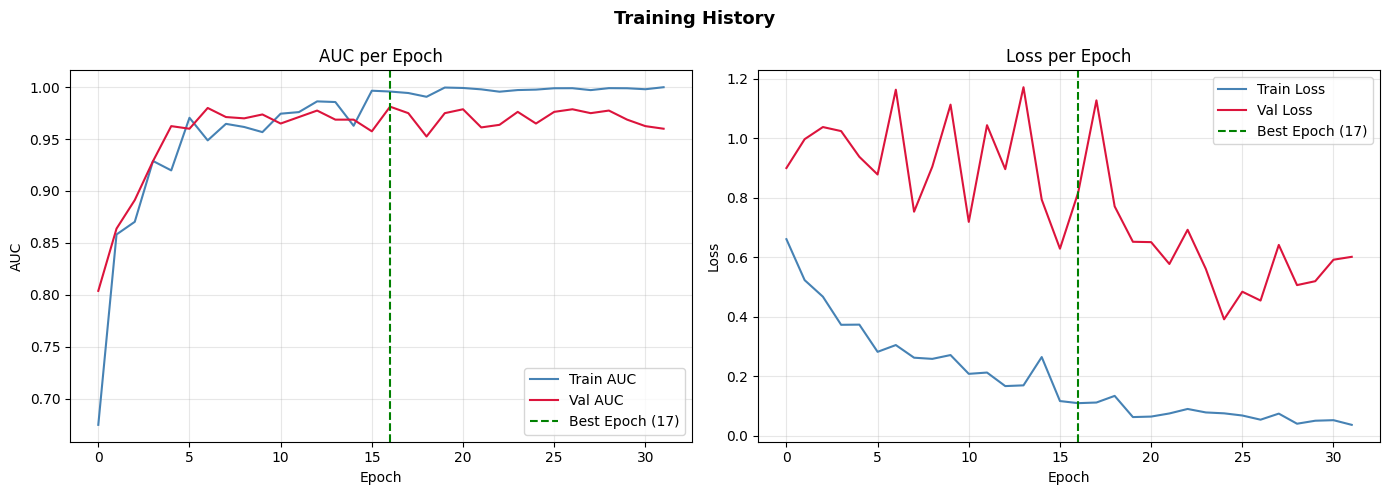

 Plot 3 saved: training_history.png

 All visualizations completed!
Generated files:
  - ecg_all_leads_comparison.png
  - ecg_v1v2v3_comparison.png
  - training_history.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get indices of Brugada and Normal patients from test set
brugada_idx = np.where(y_test == 1)[0]
normal_idx  = np.where(y_test == 0)[0]
sample_brugada = X_test[brugada_idx[0]]  # Shape: (1200, 12)
sample_normal  = X_test[normal_idx[0]]   # Shape: (1200, 12)

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

key_leads = [6, 7, 8]
time_axis = np.arange(1200) / 100

# Plot 1: All 12 Leads
fig, axes = plt.subplots(12, 2, figsize=(16, 28))
fig.suptitle('ECG Comparison: Brugada vs Normal\n(All 12 Leads)',
             fontsize=14, fontweight='bold', y=1.01)

for i in range(12):
    axes[i, 0].plot(time_axis, sample_normal[:, i], color='steelblue', linewidth=0.8)
    axes[i, 0].set_ylabel(lead_names[i], fontsize=9)
    axes[i, 0].set_ylim(-3, 3)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Normal', fontsize=12, color='steelblue', fontweight='bold')
    if i == 11:
        axes[i, 0].set_xlabel('Time (seconds)')

    axes[i, 1].plot(time_axis, sample_brugada[:, i], color='crimson', linewidth=0.8)
    axes[i, 1].set_ylim(-3, 3)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Brugada', fontsize=12, color='crimson', fontweight='bold')
    if i == 11:
        axes[i, 1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('ecg_all_leads_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 1 saved: ecg_all_leads_comparison.png")

# Plot 2: Focus V1-V3
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Focus on Leads V1–V3: Brugada Characteristics\n(ST Segment Elevation)',
             fontsize=13, fontweight='bold')

for row, lead_idx in enumerate(key_leads):
    axes[row, 0].plot(time_axis, sample_normal[:, lead_idx],
                      color='steelblue', linewidth=1.2)
    axes[row, 0].set_ylabel(f'{lead_names[lead_idx]} (mV)', fontsize=10)
    axes[row, 0].set_ylim(-3, 3)
    axes[row, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[row, 0].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 0].set_title('Normal', fontsize=12,
                                color='steelblue', fontweight='bold')
    if row == 2:
        axes[row, 0].set_xlabel('Time (seconds)')

    axes[row, 1].plot(time_axis, sample_brugada[:, lead_idx],
                      color='crimson', linewidth=1.2)
    axes[row, 1].set_ylim(-3, 3)
    axes[row, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[row, 1].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 1].set_title('Brugada', fontsize=12,
                                color='crimson', fontweight='bold')
    if row == 2:
        axes[row, 1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('ecg_v1v2v3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 2 saved: ecg_v1v2v3_comparison.png")

# Plot 3: Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

# AUC
axes[0].plot(history.history['auc'], color='steelblue', label='Train AUC')
axes[0].plot(history.history['val_auc'], color='crimson', label='Val AUC')
axes[0].axvline(x=16, color='green', linestyle='--', label='Best Epoch (17)')
axes[0].set_title('AUC per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], color='steelblue', label='Train Loss')
axes[1].plot(history.history['val_loss'], color='crimson', label='Val Loss')
axes[1].axvline(x=16, color='green', linestyle='--', label='Best Epoch (17)')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 3 saved: training_history.png")

print("\n All visualizations completed!")
print("Generated files:")
print("  - ecg_all_leads_comparison.png")
print("  - ecg_v1v2v3_comparison.png")
print("  - training_history.png")